In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./category_sum2.csv')

In [2]:
df

,Unnamed: 0,주차,라인,성별,기획년도,시즌이월,상품년차,시즌,복종,소품종,카테고리,할인율,판매액,판매수량,매출원가,판매택가
0,0,2021-01-03,ZA,1:남성,2021,01_시즌,당해년도,봄,가죽&FUR,가죽점퍼,가죽&FUR_가죽점퍼_ZA,1.130573,52297400,53,10846000,52947000
1,1,2021-01-03,ZA,1:남성,2021,01_시즌,당해년도,봄,수트,블레이져(수트),수트_블레이져(수트)_ZA,39.444496,19685400,109,5717811,35131000
2,2,2021-01-03,ZA,1:남성,2021,01_시즌,당해년도,봄,수트,수트팬츠,수트_수트팬츠_ZA,39.896443,12921890,128,3853581,23232000
3,3,2021-01-03,ZB,1:남성,2021,01_시즌,당해년도,봄,니트 셔츠,라운드,니트 셔츠_라운드_ZB,32.281514,18981424,401,3559559,28029900
4,4,2021-01-03,ZB,1:남성,2021,01_시즌,당해년도,봄,수트,블레이져(수트),수트_블레이져(수트)_ZB,-0.265138,29890941,194,7913293,38606000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12577,12577,2024-12-29,ZG,1:남성,2024,01_시즌,당해년도,겨울,팬츠,팬츠(일반),팬츠_팬츠(일반)_ZG,51.695349,311565,5,85101,645000
12578,12578,2024-12-29,ZG,1:남성,2024,02_이월,당해년도,여름,니트 셔츠,라운드,니트 셔츠_라운드_ZG,0.000000,0,0,0,0
12579,12579,2024-12-29,ZG,1:남성,2024,02_이월,당해년도,여름,점퍼,점퍼,점퍼_점퍼_ZG,0.000000,0,0,0,0
12580,12580,2024-12-29,ZG,1:남성,2024,02_이월,당해년도,여름,팬츠,반바지,팬츠_반바지_ZG,0.000000,0,0,0,0


In [3]:
category_filter = [
    '자켓_싱글재킷_ZA', '자켓_싱글재킷_ZB', '점퍼_점퍼_ZA', '점퍼_점퍼_ZB', '점퍼_점퍼_ZG',
    '점퍼_패딩점퍼_ZB', '코트_더블코트_ZA', '코트_더블코트_ZB', '코트_싱글코트_ZA', '코트_싱글코트_ZB',
    '사파리_패딩사파리_ZA', '사파리_패딩사파리_ZB', '가죽&FUR_가죽점퍼_ZA'
]

filtered_df = df[df['카테고리'].isin(category_filter)]
filtered_df

,Unnamed: 0,주차,라인,성별,기획년도,시즌이월,상품년차,시즌,복종,소품종,카테고리,할인율,판매액,판매수량,매출원가,판매택가
0,0,2021-01-03,ZA,1:남성,2021,01_시즌,당해년도,봄,가죽&FUR,가죽점퍼,가죽&FUR_가죽점퍼_ZA,1.130573,52297400,53,10846000,52947000
11,11,2021-01-03,ZB,1:남성,2021,01_시즌,당해년도,봄,코트,더블코트,코트_더블코트_ZB,0.000000,14805000,45,1543099,14805000
12,12,2021-01-03,ZB,1:남성,2021,01_시즌,당해년도,봄,코트,싱글코트,코트_싱글코트_ZB,0.126582,19646100,79,1999797,19671000
21,21,2021-01-10,ZA,1:남성,2021,01_시즌,당해년도,봄,가죽&FUR,가죽점퍼,가죽&FUR_가죽점퍼_ZA,60.724419,44542500,108,22111000,107892000
32,32,2021-01-10,ZB,1:남성,2021,01_시즌,당해년도,봄,점퍼,패딩점퍼,점퍼_패딩점퍼_ZB,24.878345,19134988,128,2474953,25472000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12549,12549,2024-12-29,ZB,1:남성,2024,02_이월,당해년도,봄,자켓,싱글재킷,자켓_싱글재킷_ZB,100.000000,0,-1,-29549,-299000
12550,12550,2024-12-29,ZB,1:남성,2024,02_이월,당해년도,봄,코트,싱글코트,코트_싱글코트_ZB,0.000000,0,0,0,0
12559,12559,2024-12-29,ZB,1:남성,2024,02_이월,당해년도,여름,점퍼,점퍼,점퍼_점퍼_ZB,0.000000,0,0,0,0
12576,12576,2024-12-29,ZG,1:남성,2024,01_시즌,당해년도,겨울,점퍼,점퍼,점퍼_점퍼_ZG,58.532300,160480,3,63571,387000


In [4]:
filtered_df.dtypes

Unnamed: 0      int64
주차             object
라인             object
성별             object
기획년도            int64
시즌이월           object
상품년차           object
시즌             object
복종             object
소품종            object
카테고리           object
할인율           float64
판매액             int64
판매수량            int64
매출원가            int64
판매택가            int64
dtype: object

In [5]:
filtered_df['주차'] = pd.to_datetime(filtered_df['주차'])
sorted_df = filtered_df.sort_values(by=['주차', '카테고리']) 
sorted_df

C:\Users\je\AppData\Local\Temp\ipykernel_4068\2790836169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['주차'] = pd.to_datetime(filtered_df['주차'])


,Unnamed: 0,주차,라인,성별,기획년도,시즌이월,상품년차,시즌,복종,소품종,카테고리,할인율,판매액,판매수량,매출원가,판매택가
0,0,2021-01-03,ZA,1:남성,2021,01_시즌,당해년도,봄,가죽&FUR,가죽점퍼,가죽&FUR_가죽점퍼_ZA,1.130573,52297400,53,10846000,52947000
11,11,2021-01-03,ZB,1:남성,2021,01_시즌,당해년도,봄,코트,더블코트,코트_더블코트_ZB,0.000000,14805000,45,1543099,14805000
12,12,2021-01-03,ZB,1:남성,2021,01_시즌,당해년도,봄,코트,싱글코트,코트_싱글코트_ZB,0.126582,19646100,79,1999797,19671000
21,21,2021-01-10,ZA,1:남성,2021,01_시즌,당해년도,봄,가죽&FUR,가죽점퍼,가죽&FUR_가죽점퍼_ZA,60.724419,44542500,108,22111000,107892000
32,32,2021-01-10,ZB,1:남성,2021,01_시즌,당해년도,봄,점퍼,패딩점퍼,점퍼_패딩점퍼_ZB,24.878345,19134988,128,2474953,25472000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12527,12527,2024-12-29,ZB,1:남성,2024,01_시즌,당해년도,겨울,점퍼,패딩점퍼,점퍼_패딩점퍼_ZB,70.240762,98737325,990,42828673,318610000
12497,12497,2024-12-29,ZA,1:남성,2024,01_시즌,당해년도,겨울,코트,더블코트,코트_더블코트_ZA,60.160311,33199608,167,13703135,83333000
12498,12498,2024-12-29,ZA,1:남성,2024,01_시즌,당해년도,겨울,코트,싱글코트,코트_싱글코트_ZA,61.099531,209409438,1008,82442548,531192000
12529,12529,2024-12-29,ZB,1:남성,2024,01_시즌,당해년도,겨울,코트,싱글코트,코트_싱글코트_ZB,63.042265,173514073,1358,84776670,489542000


In [6]:
filtered_df.dtypes

Unnamed: 0             int64
주차            datetime64[ns]
라인                    object
성별                    object
기획년도                   int64
시즌이월                  object
상품년차                  object
시즌                    object
복종                    object
소품종                   object
카테고리                  object
할인율                  float64
판매액                    int64
판매수량                   int64
매출원가                   int64
판매택가                   int64
dtype: object

In [7]:
colums = ['판매액', '판매수량', '실판매가', '판매택가', '할인율']

## 각 지표 추이(카테고리별 그래프 따로 확인)

### 판매액

C:\Users\je\AppData\Local\Temp\ipykernel_4068\3135146835.py:21: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.tight_layout()
c:\Users\je\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


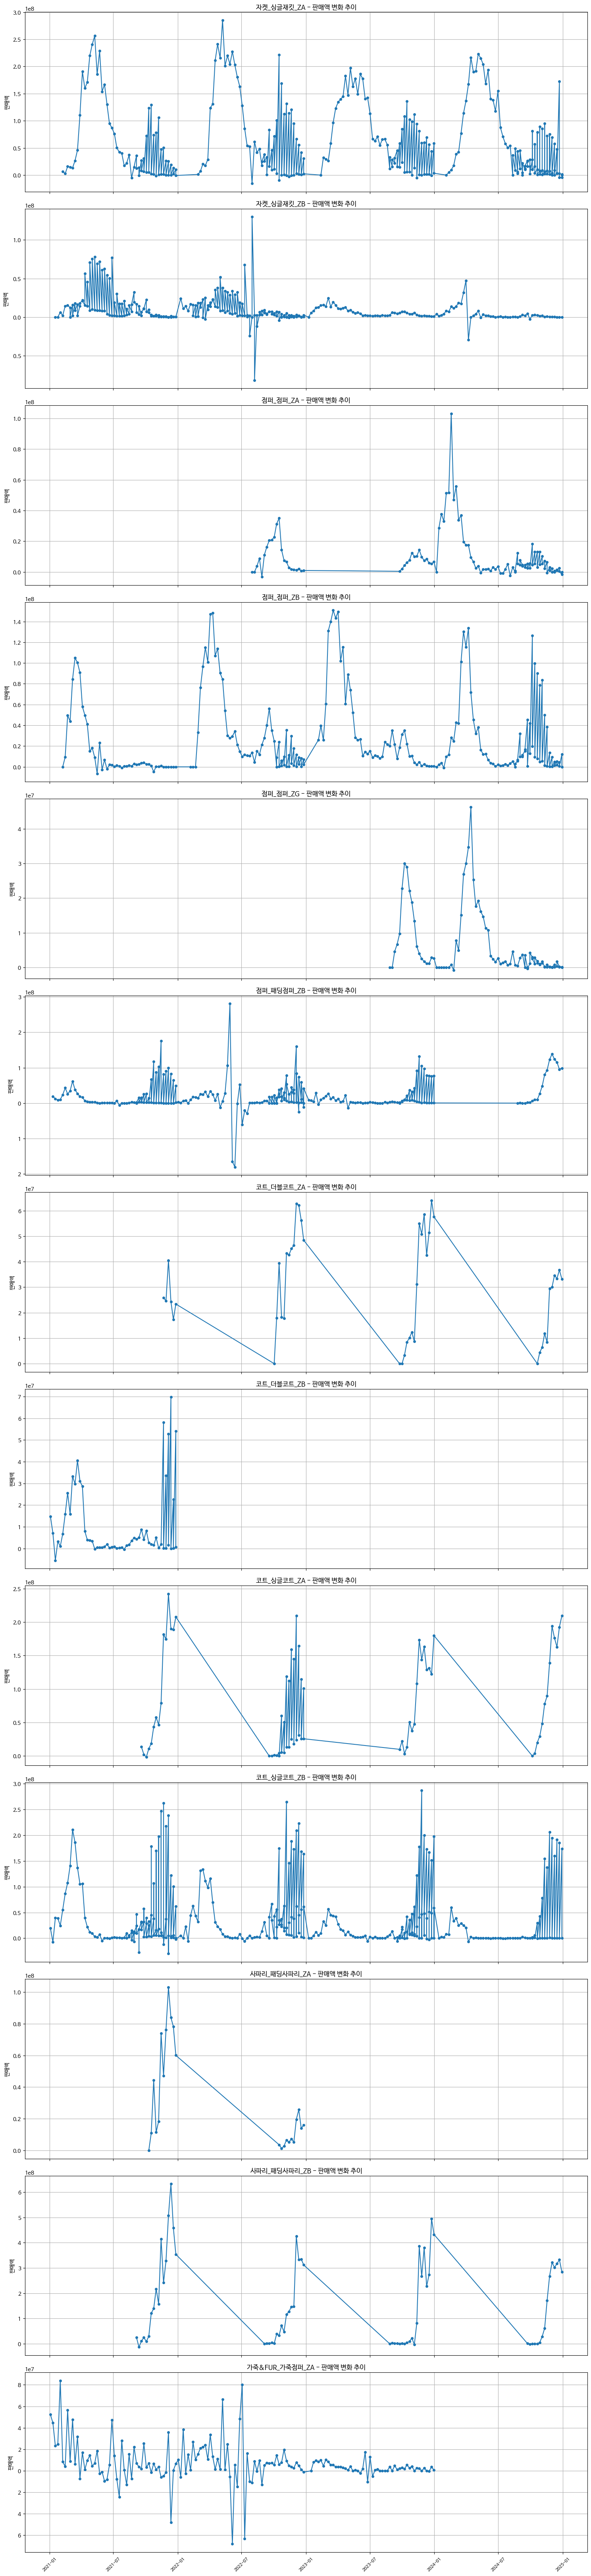

In [ ]:
fig, axes = plt.subplots(len(category_filter), 1, figsize=(15, 5 * len(category_filter)), sharex=True)

for i, category in enumerate(category_filter): 
    ax = axes[i]  
    filtered_category_df = sorted_df[sorted_df['카테고리'] == category]

    ax.plot(filtered_category_df['주차'], filtered_category_df['판매액'], marker='o', linestyle='-', markersize=4)
    ax.set_title(f'{category} - 판매액 변화 추이', fontsize=12)
    ax.set_ylabel('판매액', fontsize=10)
    ax.grid()

    ax.tick_params(axis='x', labelrotation=45, labelsize=8)


plt.tight_layout()
plt.show()